**Uso de APIs en Finanzas - Ejemplos en Python**
==
*Magister Jorge Córdoba*
===
### Cualquier duda sobre estos códigos o querés profundizar sobre los mismos, escribime por MD a **@cefcapacitar**


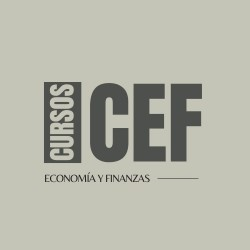

---
## 🌐 ¿Qué es una API?

Una **API** (*Application Programming Interface*) es un conjunto de protocolos y definiciones que permite la **comunicación entre sistemas de software**. Actúa como intermediario, facilitando el intercambio de datos y funcionalidades entre aplicaciones, sin exponer su código interno.

En finanzas, las APIs son fundamentales: nos permiten acceder en tiempo real a datos de mercado, cotizaciones de monedas, series macroeconómicas y precios de activos, directamente desde Python, sin necesidad de descargar archivos manualmente.

En este notebook vamos a explorar **tres fuentes de datos reales** muy relevantes para el análisis financiero:

| # | Fuente | Tipo de datos |
|---|--------|---------------|
| 1 | **BCRA** (Banco Central de la República Argentina) | Cotizaciones de divisas |
| 2 | **Yahoo Finance** (`yfinance`) | Precios de acciones, métricas financieras |
| 3 | **datos.gob.ar** | Índices de inflación (IPC) |

---

## 🏦 Parte 1 — API del BCRA: Cotizaciones de Divisas

El Banco Central de la República Argentina publica una API pública con información cambiaria actualizada. El endpoint que vamos a utilizar nos devuelve las cotizaciones oficiales de todas las monedas negociadas en el mercado cambiario argentino para el día más reciente disponible.

### ¿Qué campos nos devuelve?
- `codigoMoneda`: código ISO de la moneda (ej: `USD`, `EUR`, `BRL`)
- `descripcion`: nombre de la moneda
- `tipoPase`: tipo de pase (en unidades de la moneda extranjera por peso)
- `tipoCotizacion`: cotización en pesos argentinos

> ⚠️ **Nota técnica:** El servidor del BCRA no siempre tiene un certificado SSL válido reconocido. Por eso se usa `verify=False` para evitar errores de conexión. En entornos de producción, lo ideal es gestionar correctamente el certificado. Para suprimir el aviso, importamos `urllib3` y desactivamos el warning puntualmente.

In [ ]:
import requests
import urllib3

# Suprimimos el warning de SSL ya que el servidor del BCRA no siempre tiene certificado válido
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

url = 'https://api.bcra.gob.ar//estadisticascambiarias/v1.0/Cotizaciones/'
response = requests.get(url, verify=False)

if response.status_code == 200:
    data = response.json()
    print(f"\n------- Cotizaciones del día {data['results']['fecha']} -------\n")
    for result in data['results']['detalle']:
        cod  = result['codigoMoneda']
        desc = result['descripcion']
        cot  = result['tipoCotizacion']
        if cot > 0:  # Mostramos solo las monedas con cotización disponible
            print(f"  {cod:5s} | {desc:<40s} | ARS {cot:>12.4f}")
else:
    print(f"Error al conectar con la API del BCRA. Código: {response.status_code}")

---
## 📈 Parte 2 — API de Yahoo Finance (`yfinance`)

**Yahoo Finance** es una de las fuentes más populares para obtener datos financieros de mercados globales. La librería `yfinance` en Python nos permite acceder a esta información de forma sencilla.

### ¿Qué podemos obtener?
- **Información fundamental** de la empresa (sector, empleados, márgenes, ratios financieros)
- **Historial de precios** (apertura, máximo, mínimo, cierre, volumen)
- **Métricas de mercado** (beta, P/E, capitalización bursátil, etc.)

A lo largo de esta sección trabajaremos principalmente con **MercadoLibre (MELI)** y **Amazon (AMZN)**, dos gigantes del e-commerce que cotizan en el Nasdaq.

In [ ]:
import yfinance as yf
from datetime import date, datetime, timedelta

print("Librería yfinance importada correctamente ✅")

### 2.1 — Información fundamental de MercadoLibre (MELI)

El método `.info` de un objeto `Ticker` devuelve un diccionario con decenas de datos sobre la empresa: desde su dirección y descripción hasta métricas financieras actualizadas como el P/E ratio, capitalización de mercado, deuda, márgenes y más.

Acá vamos a mostrar solo los **campos más relevantes** para un análisis financiero básico, en lugar de imprimir el diccionario completo.

In [ ]:
meli = yf.Ticker("MELI")
info = meli.info

# Campos relevantes para análisis financiero
campos = {
    "Empresa"                   : info.get('longName', 'N/D'),
    "Sector"                    : info.get('sector', 'N/D'),
    "País"                      : info.get('country', 'N/D'),
    "Empleados (tiempo completo)": info.get('fullTimeEmployees', 'N/D'),
    "Capitalización de mercado" : f"USD {info.get('marketCap', 0):,.0f}",
    "Precio actual"             : f"USD {info.get('currentPrice', 0):.2f}",
    "P/E Trailing"              : info.get('trailingPE', 'N/D'),
    "P/E Forward"               : info.get('forwardPE', 'N/D'),
    "Beta"                      : info.get('beta', 'N/D'),
    "Margen neto"               : f"{info.get('profitMargins', 0)*100:.2f}%",
    "ROE"                       : f"{info.get('returnOnEquity', 0)*100:.2f}%",
    "Recomendación analistas"   : info.get('recommendationKey', 'N/D').upper(),
    "Precio objetivo (media)"   : f"USD {info.get('targetMeanPrice', 0):.2f}",
}

print("📊 Resumen fundamental — MercadoLibre (MELI)\n")
for k, v in campos.items():
    print(f"  {k:<35s}: {v}")

### 2.2 — Historial de precios de MELI

El método `.history()` nos permite descargar el **historial completo de precios** de un activo. Los parámetros más usados son:
- `period`: período de tiempo (`"1mo"`, `"6mo"`, `"1y"`, `"max"`)
- `start` / `end`: para especificar un rango de fechas exacto

El resultado es un `DataFrame` de pandas con columnas: `Open`, `High`, `Low`, `Close`, `Volume`, `Dividends`, `Stock Splits`.

Descargamos aquí el historial completo desde el IPO de MELI (agosto 2007).

In [ ]:
historial = meli.history(period="max")

print(f"📅 Período disponible: {historial.index[0].date()} → {historial.index[-1].date()}")
print(f"📦 Total de sesiones: {len(historial):,} días hábiles\n")
print(historial[['Open', 'High', 'Low', 'Close', 'Volume']].tail(10).round(2))

### 2.3 — Descarga de múltiples activos simultáneamente

Con `yf.download()` podemos descargar datos de **varios tickers al mismo tiempo**, lo cual es muy útil para comparar activos o construir portafolios.

El resultado es un `DataFrame` con índice jerárquico: el primer nivel corresponde a la variable de precio (`Close`, `Open`, etc.) y el segundo al ticker.

> 💡 **Tip:** Usamos `auto_adjust=True` para obtener precios ya ajustados por dividendos y splits, que es el estándar para análisis de retornos.

In [ ]:
tickers = ["AMZN", "MELI"]

data = yf.download(tickers, start="2025-01-01", auto_adjust=True, progress=False)

# Mostramos solo los precios de cierre
cierres = data['Close']
print(f"📊 Precios de cierre ajustados — AMZN y MELI (desde 2025-01-01)\n")
print(f"  Filas descargadas: {len(cierres):,}")
print(f"  Fecha inicio: {cierres.index[0].date()}")
print(f"  Fecha fin:    {cierres.index[-1].date()}\n")
print(cierres.tail(10).round(2))

---
## 📐 Parte 3 — Beta: Medida de Riesgo Sistemático

El **Beta (β)** es uno de los indicadores más importantes en finanzas corporativas y en el modelo CAPM. Mide la **sensibilidad del retorno de un activo respecto al mercado**:

- **β = 1**: el activo se mueve exactamente igual que el mercado
- **β > 1**: el activo es más volátil que el mercado (más riesgo sistemático)
- **β < 1**: el activo es menos volátil que el mercado
- **β < 0**: el activo se mueve en dirección contraria al mercado (muy inusual)

Yahoo Finance publica el beta calculado sobre una ventana histórica de 5 años respecto al S&P 500.

### 3.1 — Obtener el beta de un único ticker

In [ ]:
beta_meli = meli.info.get('beta', 'No disponible')
print(f"🔢 Beta de MercadoLibre (MELI): {beta_meli}")
print("   → MELI es más volátil que el mercado (β > 1)" if isinstance(beta_meli, (int, float)) and beta_meli > 1 else "")

### 3.2 — Función reutilizable para consultar el beta de múltiples empresas

A continuación definimos una función `obtener_betas()` que recibe una lista de tickers y devuelve el beta de cada uno. Esto es mucho más práctico cuando queremos comparar varias empresas de forma rápida.

Notar el uso de `*args` para pasar un número variable de tickers como argumentos posicionales.

In [ ]:
def obtener_betas(*tickers):
    """
    Imprime el beta de cada empresa dada su clave de ticker.
    Ejemplo de uso: obtener_betas('MELI', 'AMZN', 'GGAL')
    """
    print("📐 Betas de las empresas seleccionadas:\n")
    for ticker in tickers:
        empresa = yf.Ticker(ticker)
        beta = empresa.info.get('beta', 'No disponible')
        print(f"  {ticker:8s} → β = {beta}")

In [ ]:
# Llamamos a la función con los tickers que queremos analizar
obtener_betas('MELI', 'AMZN')

### 3.3 — Alternativa: usando un bucle con una lista

El mismo resultado puede obtenerse iterando sobre una lista de tickers, lo que resulta útil cuando los tickers están almacenados en una variable (por ejemplo, proveniente de una base de datos o de un archivo).

In [ ]:
empresas = ['MELI', 'AMZN']

print("📐 Betas (versión con lista):\n")
for ticker in empresas:
    empresa = yf.Ticker(ticker)
    beta = empresa.info.get('beta', 'No disponible')
    print(f"  {ticker:8s} → β = {beta}")

---
## 📅 Parte 4 — Últimos precios de cierre y S&P 500

### 4.1 — Últimos 10 días hábiles de MELI

Muchos análisis financieros requieren los **N días hábiles más recientes** de un activo. Aquí usamos un período de 30 días para asegurarnos de obtener al menos 10 ruedas bursátiles (descontando fines de semana y feriados), y luego filtramos con `.tail(10)`.

In [ ]:
ticker_meli = yf.Ticker("MELI")
hist_reciente = ticker_meli.history(period="30d")  # Período más largo para garantizar 10 días hábiles
cierres_recientes = hist_reciente["Close"].dropna().tail(10)

print("📅 Últimos 10 cierres de MELI:\n")
for fecha, precio in cierres_recientes.items():
    print(f"  {str(fecha.date()):12s}  →  USD {precio:>10.2f}")

variacion = ((cierres_recientes.iloc[-1] / cierres_recientes.iloc[0]) - 1) * 100
print(f"\n  Variación acumulada en el período: {variacion:+.2f}%")

### 4.2 — Descarga del índice S&P 500

El **S&P 500** (`^GSPC`) es el índice de referencia más utilizado en el mundo para medir el desempeño del mercado accionario estadounidense. En yfinance se accede usando el ticker `"^GSPC"`.

Descargamos datos desde enero 2020 hasta hoy para tener un contexto de 5 años que incluye el crash COVID, la recuperación y el ciclo de tasas.

> 📌 Usamos `date.today()` para que siempre se descargue hasta la fecha más reciente disponible.

In [ ]:
today = date.today()

sp500 = yf.download("^GSPC", start="2020-01-01", end=today, auto_adjust=True, progress=False)

print("📈 S&P 500 — Datos descargados:\n")
print(f"  Período:         {sp500.index[0].date()} → {sp500.index[-1].date()}")
print(f"  Sesiones:        {len(sp500):,} días hábiles")
print(f"  Cierre mínimo:   {sp500['Close'].min().values[0]:,.2f}")
print(f"  Cierre máximo:   {sp500['Close'].max().values[0]:,.2f}")
print(f"  Último cierre:   {sp500['Close'].iloc[-1].values[0]:,.2f}\n")
print(sp500[['Close', 'Volume']].tail(5).round(2))

---
## 🪙 Parte 5 — API de Criptomonedas con CoinGecko

Para obtener datos de criptomonedas usamos la **API pública de CoinGecko**, que no requiere instalación de librerías adicionales ni registro, y funciona sin restricciones geográficas desde cualquier entorno (incluyendo Google Colab).

CoinGecko agrega datos de más de 600 exchanges y es una de las fuentes más completas del mercado crypto. Con su API gratuita podemos obtener:

- **Precios actuales** de miles de criptomonedas en cualquier moneda
- **Capitalización de mercado** y volumen operado en 24h
- **Variación de precio** en las últimas 24 horas
- **Historial de precios** con diferentes granularidades

> 📌 La API pública tiene un límite de ~30 llamadas por minuto, más que suficiente para análisis y enseñanza.

In [ ]:
import requests
import pandas as pd

# CoinGecko — precios actuales de las principales criptomonedas
# El parámetro 'ids' acepta los IDs propios de CoinGecko (no los tickers de exchange)
cryptos = {
    'bitcoin'       : 'BTC',
    'ethereum'      : 'ETH',
    'binancecoin'   : 'BNB',
    'solana'        : 'SOL',
    'ripple'        : 'XRP',
}

ids_string = ','.join(cryptos.keys())

url = (
    "https://api.coingecko.com/api/v3/coins/markets"
    f"?vs_currency=usd&ids={ids_string}"
    "&order=market_cap_desc&sparkline=false"
)

response = requests.get(url)

if response.status_code == 200:
    data_crypto = response.json()
    df_crypto = pd.DataFrame(data_crypto)[[
        'symbol', 'name', 'current_price',
        'price_change_percentage_24h', 'market_cap', 'total_volume'
    ]].rename(columns={
        'symbol'                     : 'Ticker',
        'name'                       : 'Nombre',
        'current_price'              : 'Precio (USD)',
        'price_change_percentage_24h': 'Var. 24h (%)',
        'market_cap'                 : 'Cap. de Mercado (USD)',
        'total_volume'               : 'Volumen 24h (USD)',
    })
    df_crypto['Ticker'] = df_crypto['Ticker'].str.upper()

    print("🪙 Criptomonedas — Precios actuales (fuente: CoinGecko)\n")
    for _, row in df_crypto.iterrows():
        signo = '+' if row['Var. 24h (%)'] >= 0 else ''
        print(
            f"  {row['Ticker']:5s} | "
            f"USD {row['Precio (USD)']:>12,.2f} | "
            f"24h: {signo}{row['Var. 24h (%)']:.2f}% | "
            f"Mkt Cap: USD {row['Cap. de Mercado (USD)']:>18,.0f}"
        )
else:
    print(f"Error al conectar con CoinGecko. Código HTTP: {response.status_code}")

### 5.2 — Historial de precios de Bitcoin (últimos 30 días)

CoinGecko también nos permite descargar el **historial de precios** de cualquier cripto. Esto es útil para calcular retornos, volatilidad o comparar el desempeño de activos en un período determinado.

El endpoint `/coins/{id}/market_chart` devuelve una lista de pares `[timestamp, precio]` con granularidad horaria (para períodos ≤ 90 días) o diaria (para períodos mayores).

In [ ]:
# Historial de precios de Bitcoin — últimos 30 días
url_hist = "https://api.coingecko.com/api/v3/coins/bitcoin/market_chart?vs_currency=usd&days=30&interval=daily"

response_hist = requests.get(url_hist)

if response_hist.status_code == 200:
    hist_data = response_hist.json()

    # Convertir a DataFrame
    df_btc = pd.DataFrame(hist_data['prices'], columns=['timestamp', 'precio_usd'])
    df_btc['fecha'] = pd.to_datetime(df_btc['timestamp'], unit='ms').dt.date
    df_btc = df_btc[['fecha', 'precio_usd']].copy()

    # Retorno diario
    df_btc['retorno_diario'] = df_btc['precio_usd'].pct_change() * 100

    print("📅 Bitcoin — Historial últimos 30 días:\n")
    print(df_btc.tail(10).to_string(index=False))

    # Estadísticas del período
    retorno_total = ((df_btc['precio_usd'].iloc[-1] / df_btc['precio_usd'].iloc[0]) - 1) * 100
    volatilidad   = df_btc['retorno_diario'].std()
    print(f"\n  Retorno acumulado 30 días: {retorno_total:+.2f}%")
    print(f"  Volatilidad diaria (desvío estándar): {volatilidad:.2f}%")
else:
    print(f"Error. Código HTTP: {response_hist.status_code}")

---
## 📊 Parte 6 — API de datos.gob.ar: Inflación Argentina (IPC)

El portal **datos.gob.ar** del Gobierno Nacional expone una API REST que permite acceder a cientos de series estadísticas oficiales, incluyendo el **Índice de Precios al Consumidor (IPC)** publicado por el INDEC.

Vamos a consultar dos series:
1. **Índice IPC nivel general** (valor acumulado del índice base)
2. **Variación mensual del IPC** (inflación mensual en forma decimal)

El endpoint tiene la siguiente estructura:
```
https://apis.datos.gob.ar/series/api/series/?ids={serie_id}&format=json&limit=500
```

> 📌 Podés explorar todas las series disponibles en: https://datos.gob.ar/series

In [ ]:
import requests
import pandas as pd

# Serie: IPC Nivel General Nacional — índice acumulado
serie_id = "145.3_INGPAMANA_DICI_M_15"
url = f"https://apis.datos.gob.ar/series/api/series/?ids={serie_id}&format=json&limit=500"

response = requests.get(url)

if response.status_code != 200:
    print("Error:", response.text)
else:
    data = response.json()
    df_ipc = pd.DataFrame(data["data"], columns=["fecha", "valor"])
    df_ipc["fecha"] = pd.to_datetime(df_ipc["fecha"])
    df_ipc["valor"] = pd.to_numeric(df_ipc["valor"], errors="coerce")

    print("📈 IPC Nivel General — Últimos 12 meses:\n")
    print(df_ipc.tail(12).to_string(index=False))

    # Inflación mensual e interanual del último dato disponible
    if len(df_ipc) >= 2:
        ultimo = df_ipc.iloc[-1]["valor"]
        anterior = df_ipc.iloc[-2]["valor"]
        mensual = ((ultimo / anterior) - 1) * 100
        print(f"\n  ➡️  Inflación mensual (último dato disponible): {mensual:.2f}%")

    ultimo_row = df_ipc.iloc[-1]
    mismo_mes_anio_anterior = df_ipc[
        (df_ipc["fecha"].dt.year == ultimo_row["fecha"].year - 1) &
        (df_ipc["fecha"].dt.month == ultimo_row["fecha"].month)
    ]
    if not mismo_mes_anio_anterior.empty:
        base = mismo_mes_anio_anterior.iloc[0]["valor"]
        interanual = ((ultimo_row["valor"] / base) - 1) * 100
        print(f"  ➡️  Inflación interanual (último dato disponible): {interanual:.2f}%")

### 6.2 — Variación mensual del IPC

Esta segunda serie nos da directamente la **tasa de inflación mensual** (en formato decimal, donde `0.03` equivale a un 3%). Es útil para análisis de series temporales, cálculo de inflación acumulada en períodos específicos, o ajuste de flujos de fondos en términos reales.

In [ ]:
# Serie: IPC Nivel General Nacional — variación mensual
serie_id_var = "145.3_INGNACUAL_DICI_M_38"
url_var = f"https://apis.datos.gob.ar/series/api/series/?ids={serie_id_var}&format=json&limit=500"

response_var = requests.get(url_var)

if response_var.status_code != 200:
    print("Error:", response_var.text)
else:
    data_var = response_var.json()
    df_var = pd.DataFrame(data_var["data"], columns=["fecha", "valor"])
    df_var["fecha"] = pd.to_datetime(df_var["fecha"])
    df_var["valor"] = pd.to_numeric(df_var["valor"], errors="coerce")

    # Formatear como porcentaje para mejor lectura
    df_var["inflacion_pct"] = (df_var["valor"] * 100).round(2)

    print("📊 Variación mensual del IPC — Últimos 12 meses:\n")
    print(df_var[["fecha", "inflacion_pct"]].tail(12).to_string(index=False))

### 6.3 — Filtro: meses con inflación mensual superior al 3%

Un caso de uso habitual es **filtrar períodos que superan un umbral** de inflación. Este tipo de análisis es relevante, por ejemplo, para ajustar cláusulas de contratos, actualizar proyecciones financieras o identificar períodos de alta volatilidad de precios.

> ⚠️ **Mejora técnica:** el código original generaba un `UserWarning` por indexar sobre un subset del DataFrame. Aquí lo corregimos usando `.copy()` para evitar ese problema.

In [ ]:
# Tomamos los últimos 12 meses como copia para evitar warnings de pandas
ultimos_12 = df_var.tail(12).copy()

# Filtramos meses con inflación mensual superior al 3%
umbral = 0.03
alta_inflacion = ultimos_12[ultimos_12["valor"] > umbral]

print(f"🔴 Meses con inflación mensual > {umbral*100:.1f}% (últimos 12 meses):\n")

if alta_inflacion.empty:
    print("  No hubo meses con inflación superior al umbral en este período.")
else:
    for _, row in alta_inflacion.iterrows():
        print(f"  {row['fecha'].strftime('%B %Y'):20s}  →  {row['valor']*100:.2f}%")

print(f"\n  Total de meses sobre el umbral: {len(alta_inflacion)} de {len(ultimos_12)}")

---
## ✅ Resumen

A lo largo de este notebook exploramos tres APIs con aplicaciones directas en finanzas corporativas:

| API | Librería | Casos de uso |
|-----|----------|--------------|
| **BCRA** | `requests` | Tipo de cambio oficial, cotizaciones de divisas |
| **Yahoo Finance** | `yfinance` | Precios, beta, ratios financieros, S&P 500 |
| **datos.gob.ar** | `requests` + `pandas` | IPC, inflación mensual e interanual |
| **CoinGecko** | `requests` | Precios, historial y métricas de criptomonedas |

🔑 **Conceptos clave repasados:** HTTP requests, JSON, DataFrames de pandas, beta, IPC, inflación mensual e interanual.

💬 ¿Dudas? Escribime por Instagram: **@cefcapacitar**
